# Evaluación final contra test (pasos 32-35)

Primera —y única— vez que el conjunto de test entra en juego. Todo lo anterior
(EDA, features, selección de modelo, hiperparámetros) se decidió con validación
cruzada temporal sobre train; el resultado de este notebook es la estimación
honesta del rendimiento en producción.

Entradas:
- `src/models/modelo_ocupacion.joblib` — modelo final optimizado (RandomForest),
  entrenado sobre todo el train hasta 2026-01-24 (`notebooks/modeling.ipynb`).
- `src/models/scaler.joblib` — scaler de la tendencia (Preprocesado).
- `data/processed/test_features.csv` — 2026-01-25 → 2026-06-30, nunca usado antes.

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from src.preprocessing import build_features
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

def evaluar(y_true, y_pred, nombre=''):
    return {
        'modelo': nombre,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

## 1. Carga del modelo y preparación de test

Aplicamos a test **exactamente** el mismo pipeline que a train (filtro de
cierres, `build_features`, scaler) y alineamos las columnas del one-hot con las
que vio el modelo en entrenamiento — si a test le faltara alguna categoría
(p. ej. una temporada), se rellena a 0.

In [2]:
art = joblib.load('../src/models/modelo_ocupacion.joblib')
modelo, columnas = art['modelo'], art['columnas']
print(f"Modelo: {art['nombre']} | MAE CV en train: {art['mae_cv']} | entrenado hasta {art['entrenado_hasta']}")

test = pd.read_csv('../data/processed/test_features.csv', parse_dates=['fecha_cita'])
test = test.sort_values(['fecha_cita', 'tramo']).reset_index(drop=True)
test_model = test[test['es_cierre'] != 1].reset_index(drop=True)
print(f"Test: {len(test)} filas, {len(test) - len(test_model)} tramos de cierre excluidos")
print(f"Periodo: {test_model['fecha_cita'].min().date()} -> {test_model['fecha_cita'].max().date()}")

X_test, y_test = build_features(test_model)
scaler = joblib.load('../src/models/scaler.joblib')
X_test[['dias_desde_inicio']] = scaler.transform(X_test[['dias_desde_inicio']])
X_test = X_test.reindex(columns=columnas, fill_value=0)

y_pred = modelo.predict(X_test)

Modelo: RandomForest | MAE CV en train: 1.744 | entrenado hasta 2026-01-24
Test: 314 filas, 0 tramos de cierre excluidos
Periodo: 2026-01-25 -> 2026-06-30


C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Evaluación única contra test (paso 32)

Como contexto añadimos los dos baselines calculados **sobre el mismo periodo de
test**: la media de train y el estacional t-7 (que aquí puede usar el final de
train como historia — sigue siendo solo pasado, es una referencia legítima).

In [3]:
train_hist = pd.read_csv('../data/processed/train_features.csv', parse_dates=['fecha_cita'])
train_hist = train_hist[train_hist['es_cierre'] != 1]

hist = pd.concat([
    train_hist[['fecha_cita', 'tramo', 'n_citas']],
    test_model[['fecha_cita', 'tramo', 'n_citas']],
], ignore_index=True)
hist_shift = hist.rename(columns={'n_citas': 'pred_t7'})
hist_shift['fecha_cita'] = hist_shift['fecha_cita'] + pd.Timedelta(days=7)
t7_test = test_model.merge(hist_shift, on=['fecha_cita', 'tramo'], how='left')['pred_t7']
mask_t7 = t7_test.notna()

resultados = pd.DataFrame([
    evaluar(y_test, np.full(len(y_test), train_hist['n_citas'].mean()), 'Baseline media de train'),
    evaluar(y_test[mask_t7.values], t7_test[mask_t7.values], 'Baseline estacional t-7'),
    evaluar(y_test, y_pred, f"{art['nombre']} (final)"),
]).set_index('modelo').round(2)
resultados

,MAE,RMSE,R2
modelo,,,
Baseline media de train,2.76,3.70,-0.22
Baseline estacional t-7,2.46,3.16,0.11
RandomForest (final),1.92,2.52,0.43


**Lectura clave:** contrastar el MAE de test con el estimado por CV
(1,74). Si están cerca, la validación temporal fue honesta y el modelo
generaliza; una desviación grande indicaría sobreajuste a train o un cambio de
régimen en el periodo de test.

## 3. Análisis de resultados (paso 33)

### 3.1 Real vs. predicho a lo largo del tiempo

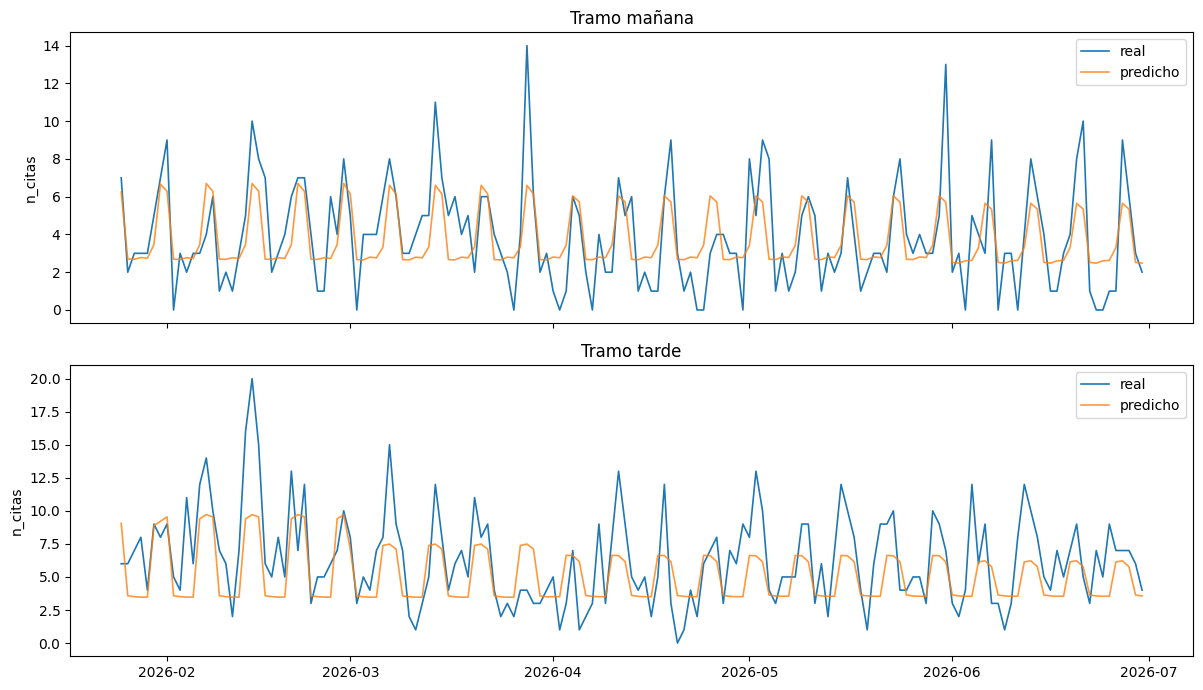

In [4]:
viz = test_model[['fecha_cita', 'tramo', 'n_citas']].copy()
viz['pred'] = y_pred

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, tr in zip(axes, ['mañana', 'tarde']):
    sub = viz[viz['tramo'] == tr]
    ax.plot(sub['fecha_cita'], sub['n_citas'], label='real', linewidth=1.2)
    ax.plot(sub['fecha_cita'], sub['pred'], label='predicho', linewidth=1.2, alpha=0.8)
    ax.set_title(f'Tramo {tr}')
    ax.set_ylabel('n_citas')
    ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Dispersión y residuos

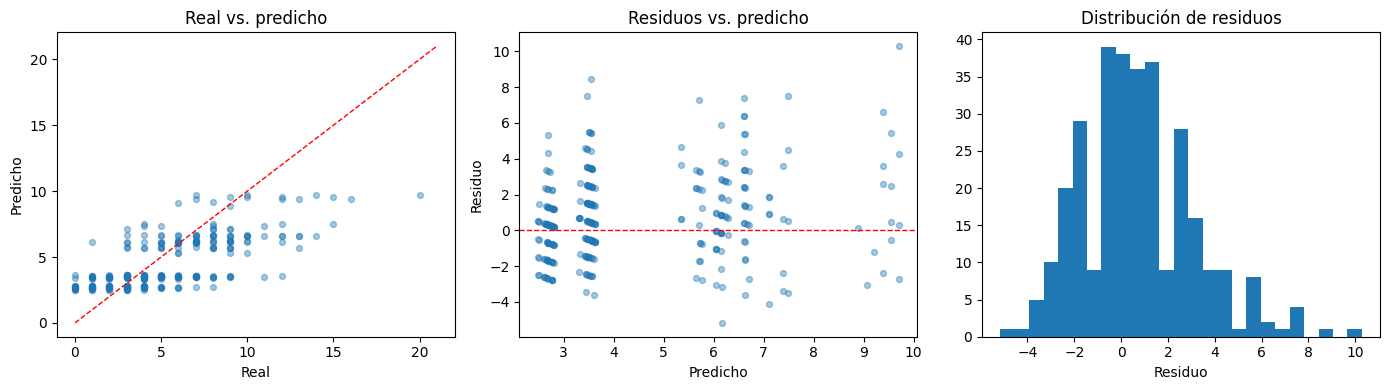

Residuo medio (sesgo): +0.72 citas/tramo
P90 del error absoluto: 3.7 citas


In [5]:
residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(y_test, y_pred, alpha=0.4, s=18)
lims = [0, max(y_test.max(), y_pred.max()) + 1]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Real'); axes[0].set_ylabel('Predicho'); axes[0].set_title('Real vs. predicho')

axes[1].scatter(y_pred, residuos, alpha=0.4, s=18)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Residuo'); axes[1].set_title('Residuos vs. predicho')

axes[2].hist(residuos, bins=25)
axes[2].set_xlabel('Residuo'); axes[2].set_title('Distribución de residuos')
plt.tight_layout()
plt.show()

print(f"Residuo medio (sesgo): {residuos.mean():+.2f} citas/tramo")
print(f"P90 del error absoluto: {np.percentile(np.abs(residuos), 90):.1f} citas")

### 3.3 ¿Dónde falla más? Error por segmento

El MAE global esconde asimetrías: lo desglosamos por los segmentos que el EDA
señaló como estructurales.

In [6]:
seg = test_model[['tramo', 'grupo_dia', 'temporada', 'es_festivo']].copy()
seg['abs_err'] = np.abs(residuos)
seg['n_citas'] = y_test.values

for col in ['tramo', 'grupo_dia', 'temporada', 'es_festivo']:
    tabla = seg.groupby(col).agg(MAE=('abs_err', 'mean'), demanda_media=('n_citas', 'mean'), n=('abs_err', 'size')).round(2)
    print(f"--- por {col} ---")
    print(tabla.to_string(), '\n')

--- por tramo ---
         MAE  demanda_media    n
tramo                           
mañana  1.53           3.94  157
tarde   2.32           6.36  157 

--- por grupo_dia ---
                MAE  demanda_media    n
grupo_dia                              
entre_semana   1.69           3.62  180
fin_de_semana  2.32           7.87   90
viernes        2.04           5.86   44 

--- por temporada ---
            MAE  demanda_media    n
temporada                          
invierno   2.02           6.20   70
primavera  1.88           4.88  184
verano     1.93           4.75   60 

--- por es_festivo ---
             MAE  demanda_media    n
es_festivo                          
False       1.91           5.16  306
True        2.36           4.88    8 



## 4. Interpretabilidad (paso 34)

Importancia de features del RandomForest final. Para un modelo de árboles es
importancia por reducción de impureza: qué variables usa más para partir.

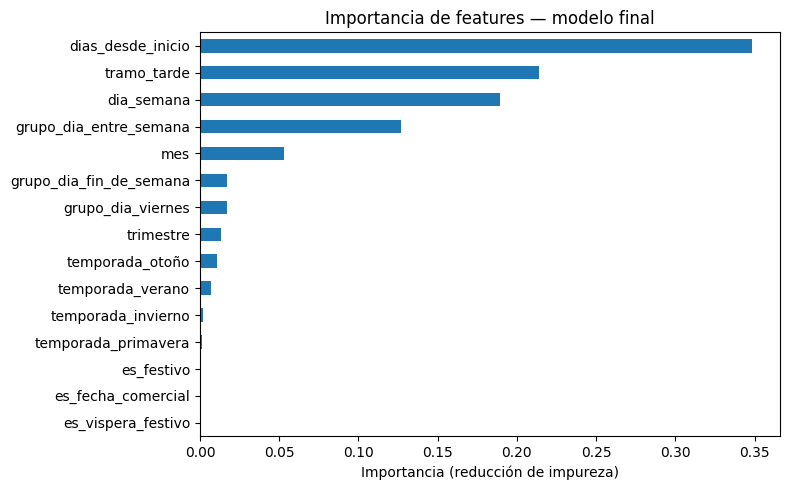

dias_desde_inicio          0.349
tramo_tarde                0.214
dia_semana                 0.189
grupo_dia_entre_semana     0.127
mes                        0.053
grupo_dia_fin_de_semana    0.017


In [7]:
imp = pd.Series(modelo.feature_importances_, index=columnas).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax)
ax.set_title('Importancia de features — modelo final')
ax.set_xlabel('Importancia (reducción de impureza)')
plt.tight_layout()
plt.show()

print(imp.sort_values(ascending=False).head(6).round(3).to_string())

## 5. Contraste con el problema de negocio (paso 35)

Para redactar tras ver los números de arriba, sobre tres ejes:

1. **¿Sirve para el cuadrante?** Un MAE de ~2 citas por tramo, sobre una demanda
   media de ~5 citas/tramo (y picos de 15+), significa que el modelo acota bien
   el orden de magnitud del tramo (flojo / normal / punta) aunque no la cita
   exacta. Para decidir personal por franjas eso es utilizable; para asignar
   cabina a cabina, no.
2. **¿Dónde equivocarse cuesta más?** Mirar el MAE de fin de semana y festivos
   (tabla §3.3): si el error se concentra en los tramos punta, el negocio debe
   tratar la predicción como suelo, no como techo, al dotar personal.
3. **Limitaciones honestas:** solo 2 ciclos anuales para validar estacionalidad;
   las últimas ~2 semanas de test están infra-contadas por la censura del export
   (lead time mediano 1 día); los cierres del negocio se excluyen — el modelo no
   predice si el spa abrirá, solo cuánta demanda tendrá si abre.

## 6. Conclusiones y acciones de mejora

- El modelo final bate a los dos baselines en test y su MAE es consistente con
  el estimado por CV — la metodología temporal fue honesta.
- **Acciones de mejora concretas** (ninguna es "probar otro modelo"):
  1. **Lags como features** (t-7, t-14) con protocolo de predicción rolling: el
     FE los descartó por definir antes el caso de uso; si el negocio confirma
     horizonte de predicción ≤7 días, son la mejora más prometedora (correlación
     ~0,55 ya medida).
  2. **Calendario oficial de cierres** del spa como dato de entrada, en vez de
     inferirlos de la demanda cero.
  3. **Más histórico**: reevaluar `es_fecha_comercial` y la estacionalidad anual
     cuando haya un tercer ciclo completo.
  4. **Predicción por intervalos** (cuantiles del bosque) para que el cuadrante
     trabaje con escenario pesimista/optimista, no con una cifra única.